#Requirements

In [ ]:
from pathlib import Path
import argparse
import os
import random
import torch
import numpy as np
import pandas as pd
from datetime import datetime
import pickle
from torch.utils import data
import sys
import importlib

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
import os
from pathlib import Path

# Define the new directory and change the current working directory
new_directory = r'/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan'
os.chdir(new_directory)

# Verify the change
print("New Current Directory:", os.getcwd())

New Current Directory: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
#Install the required packages
!pip install fair-esm
!pip install tape_proteins
!pip install transformers
!pip install rdkit-pypi
!pip install pypdb
!pip install tpot
!pip install tap
!pip install levenshtein

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
def modify_mc_bin_client():
    file_path = '/usr/local/lib/python3.11/dist-packages/mc_bin_client/mc_bin_client.py'

    # Check if the file exists
    if not os.path.exists(file_path):
        print(f"File {file_path} does not exist.")
        return

    # Read the file
    with open(file_path, 'r') as file:
        file_contents = file.read()

    # Replace the outdated exception handling syntax
    modified_contents = file_contents.replace('except MemcachedError, e:', 'except MemcachedError as e:')

    # Replace the exceptions.Exception
    modified_contents = modified_contents.replace('exceptions.Exception', 'Exception')


    # Remove the import of the non-existent 'exceptions' module
    modified_contents = modified_contents.replace('import exceptions', '')

    # Apply new modifications
    # Replace imports from memcacheConstants with relative imports
    modified_contents = modified_contents.replace('from memcacheConstants import', 'from .memcacheConstants import')

    if 'from . import memcacheConstants' not in modified_contents:
        modified_contents = modified_contents.replace('import memcacheConstants', 'from . import memcacheConstants')


    # Write the modified contents back to the file
    with open(file_path, 'w') as file:
        file.write(modified_contents)

    print(f"File {file_path} has been modified.")

def create_exceptions_file():
    import os

    # Define the directory and file path
    directory = '/usr/local/lib/python3.11/dist-packages/mc_bin_client'
    file_path = os.path.join(directory, 'exceptions.py')

    # Ensure the directory exists
    if not os.path.exists(directory):
        print("The directory does not exist. Please check the path.")
        return

    # Create and write to exceptions.py
    with open(file_path, 'w') as file:
        file.write('import builtins\n')

    print("exceptions.py file has been created successfully with 'import builtins'.")

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Execute the setup steps
modify_mc_bin_client()
create_exceptions_file()

File /usr/local/lib/python3.11/dist-packages/mc_bin_client/mc_bin_client.py has been modified.
exceptions.py file has been created successfully with 'import builtins'.


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
!python --version


Python 3.11.11


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
import time
import torch
import pandas as pd
from pathlib import Path

# Track GPU usage
def log_gpu_usage():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e6  # Convert bytes to MB
        reserved = torch.cuda.memory_reserved() / 1e6   # Convert bytes to MB
        print(f"GPU Memory Allocated: {allocated:.2f} MB")
        print(f"GPU Memory Reserved: {reserved:.2f} MB")
    else:
        print("GPU not available")

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


# Seq-to-func


Getting .fasta File

In [ ]:
def Get_processed_data_tuples(sequences, max_seqs_len, save_fasta=False, output_file=None):
    # Ensure the input is a list of strings
    if not all(isinstance(seq, str) for seq in sequences):
        raise ValueError("All elements in the sequences list must be strings.")

    # Filter sequences that exceed the max length
    filtered_sequences = [
        (f"seq{i+1}", seq)
        for i, seq in enumerate(sequences)
        if len(seq) <= max_seqs_len
    ]

    # Save to a FASTA file if requested
    if save_fasta:
        with open(output_file, "w") as fasta_file:
            for seq_id, seq in filtered_sequences:
                fasta_file.write(f">{seq_id}\n{seq}\n")
        print("\n>>> Fasta file has been saved in: ", output_file)
    else:
        print("\n>>> save_flag is off for fasta file.")

    return filtered_sequences


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Getting ESM-1b embedding

In [ ]:
import esm
def generate_embeddings(data_set, model_select="ESM_1B", batch_size=64, save_flag= False, output_file=None):

    print("\n")

    if model_select == "ESM_1B":
        model, alphabet = esm.pretrained.esm1b_t33_650M_UR50S()
    else:
        raise ValueError("Only 'ESM_1B' model is supported in this implementation.")

    # Prepare the batch converter
    batch_converter = alphabet.get_batch_converter()

    # Set the model to evaluation mode and move it to GPU
    model.eval()
    model.cuda()


    chunk_size = 500  # Number of sequences per chunk
    batch_counter = 0  # File counter
    seq_ids_chunk = []  # To store sequence IDs for the current chunk
    seq_all_hiddens_chunk = []  # To store all hidden states for the current chunk
    seq_encodings_chunk = []  # To store sequence representations for the current chunk

    for i in range(0, len(data_set), batch_size):
        print(f"Processing batch {i} out of {len(data_set)}")
        if i + batch_size <= len(data_set):
            batch = data_set[i:i + batch_size]
        else:
            batch = data_set[i:]

        # Process the batch
        batch_labels, batch_strs, batch_tokens = batch_converter(batch)
        batch_tokens = batch_tokens.cuda()
        with torch.no_grad():
            results = model(batch_tokens, repr_layers=[33])
        results = results["representations"][33].cpu().detach()

        for j, (_, seq) in enumerate(batch):
            seq_all_hiddens_chunk.append(results[j, 1:len(seq) + 1].numpy())
            seq_encodings_chunk.append(results[j, 1:len(seq) + 1].mean(0).numpy())
            seq_ids_chunk.append(batch_labels[j])

        # Save chunk if the accumulated sequences exceed chunk_size
        if len(seq_ids_chunk) >= chunk_size or (i + batch_size) >= len(data_set):
            output_file_name = str(output_file).replace(".p", "")
            output_file_chunk = f"{output_file_name}_{batch_counter}.p"
            seq_embedding_output = {
                "seq_embeddings": np.array(seq_encodings_chunk),  # Save all chunk encodings
                "seq_ids": seq_ids_chunk,  # Save all chunk IDs
                "seq_all_hiddens": seq_all_hiddens_chunk,  # Save all chunk hidden states
            }
            with open(output_file_chunk, "wb") as f:
                pickle.dump(seq_embedding_output, f)
            print(f"Saved embeddings chunk to {output_file_chunk}")

            # Reset variables for the next chunk
            seq_ids_chunk = []
            seq_all_hiddens_chunk = []
            seq_encodings_chunk = []
            batch_counter += 1

            print("All batches processed and saved.")

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


## Prediction

### Check to retrieve the save model

In [ ]:
import Marjan_N05B_SQembSAtt_y as N05B
importlib.reload(N05B)
from Marjan_N05B_SQembSAtt_y import ATT_dataset
from Marjan_N05B_SQembSAtt_y import SQembSAtt_Model

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Hiiiiiiiiiiiiiiiiii N05B


In [ ]:
def load_model_file(model_name):
    model_path = ""
    if model_name == "sarkysian1k_ESM1B":
        model_path = "/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Models_N05B/sarkysian_1ksampled/sarkysian_1ksampled_20240819_205947.pth"
    elif model_name == "sarkysian5k_ESM1B":
        model_path = "/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Models_N05B/sarkisyan_5ksampled/sarkisyan_5ksampled_1B_20241105_160400.pth"
    elif model_name == "sarkysian10k_ESM1B":
        model_path = "/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Models_N05B/sarkisyan_10ksampled/sarkisyan_10ksampled_1B_20241119_215807.pth"


    elif model_name == "sarkysianOrg_ESM1b":
        model_path = "/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Models_N05B/sarkisyan/sarkisyan_1B_20250117_015235.pth"


    elif model_name == "normalized_sarkysian1k_ESM1B":
        model_path = "/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Models_N05B/normalized_sarkysian_1ksampled/normalized_sarkysian_1ksampled_20240822_173529.pth"
    elif model_name == "sarkisyan_Unirep":
        model_path = "/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Models_N05B/sarkisyan_GFP/sarkisyan_GFP_Unirep_20240909_061220.pth"
    else:
        print("There is no model file with this name!!!!!!!!")

    return model_path

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
### set one of the types of the model using below list
### Note: name of model better to have only 2 parts
model_name_list = [ "sarkysian10k_ESM1B", #0
                    "sarkysianOrg_ESM1b", #1
                    "sarkisyan_Unirep"  #2
                  ]

model_name = model_name_list[1]
model_path = load_model_file(model_name)
model_params = torch.load(model_path)

# Extract hyperparameters
d_model = model_params['d_model']
d_k = model_params['d_k']
n_heads = model_params['n_heads']
d_v = model_params['d_v']
out_dim = model_params['out_dim']
d_ff = model_params['d_ff']
NN_type = model_params['NN_type']
log_value = model_params['log_value']
prpty_select = model_params['prpty_select']
data_folder = model_params['data_folder']
batch_size = model_params['batch_size']
learning_rate = model_params['learning_rate']
dataset_name = model_params['dataset_name']

# Print the variables
print("model_name: ", model_name)
print("d_model:", d_model)
print("d_k:", d_k)
print("n_heads:", n_heads)
print("d_v:", d_v)
print("out_dim:", out_dim)
print("d_ff:", d_ff)
print("NN_type:", NN_type)
print("log_value:", log_value)
print("prpty_select:", prpty_select)
print("data_folder:", data_folder)
print("batch_size:", batch_size)
print("learning_rate:", learning_rate)
print("dataset_name:", dataset_name)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-84-afab66db9343>:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted 

model_name:  sarkysianOrg_ESM1b
d_model: 1280
d_k: 256
n_heads: 1
d_v: 256
out_dim: 1
d_ff: 1280
NN_type: Reg
log_value: False
prpty_select: quantitative_function
data_folder: N_DataProcessing
batch_size: 1024
learning_rate: 0.001
dataset_name: sarkisyan


In [ ]:
model = N05B.SQembSAtt_Model(d_model=d_model, d_k=d_k, n_heads=n_heads, d_v=d_v, out_dim=out_dim, d_ff=d_ff)

# Load the state dictionary into the model
model.load_state_dict(model_params['state_dict'])
model = model.double().cuda()
model.eval()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


SQembSAtt_Model(
  (layers): EncoderLayer(
    (emb_self_attn): MultiHeadAttentionwithonekey(
      (W_Q): Linear(in_features=1280, out_features=256, bias=False)
      (W_K): Linear(in_features=1280, out_features=256, bias=False)
      (W_V): Linear(in_features=1280, out_features=256, bias=False)
      (fc_att): Linear(in_features=256, out_features=1, bias=False)
    )
    (pos_ffn): PoswiseFeedForwardNet(
      (fc): Sequential(
        (0): Linear(in_features=1280, out_features=1280, bias=True)
        (1): ReLU()
        (2): Linear(in_features=1280, out_features=1, bias=True)
      )
      (fc_1): Linear(in_features=1280, out_features=1280, bias=True)
      (fc_2): Linear(in_features=1280, out_features=1280, bias=True)
      (fc_3): Linear(in_features=1280, out_features=1, bias=True)
    )
  )
)

### Save the prediction

In [ ]:
def save_prediciton_files(N05B, model, sequences, embedding_folder, embedding_file, prpty_select, batch_size=64, save_flag= False, output_file=None):

    X_seqs_all_hiddens_list, properties_dict = N05B.dataPrepFiles(embedding_folder, embedding_file = embedding_file, properties_file= None)


    seq_data = sequences

    X_seqs_all_hiddens = []
    aa_seqs = []

    print("len(X_seqs_all_hiddens_list):", len(X_seqs_all_hiddens_list))
    print("len(seq_data):", len(seq_data))

    for j in range(len(X_seqs_all_hiddens_list)):
        # Directly append all embeddings and sequences without filtering based on y
        X_seqs_all_hiddens.append(X_seqs_all_hiddens_list[j])
        aa_seqs.append(seq_data[j])

    loader = N05B.ATT_loader_no_y_values(N05B.ATT_dataset_no_y_values, aa_seqs, X_seqs_all_hiddens, batch_size)


    y_pred = []
    sequences = []  # Collect sequences here

    for one_seq_ppt_group in loader:
        # Get embeddings and masks from the batch
        seq_rep = one_seq_ppt_group["embedding"].float().cuda()
        seq_mask = one_seq_ppt_group["mask"].float().cuda()

        seq_rep, seq_mask = seq_rep.double().cuda(), seq_mask.double().cuda()

        # Forward pass through the model
        output, _ = model(seq_rep, seq_mask)

        # Collect predictions
        output = output.view(-1).cpu().detach().numpy()  # Flatten and move to CPU
        y_pred.extend(output)

        # Collect sequences
        batch_sequences = one_seq_ppt_group["sequences"]
        sequences.extend(batch_sequences)

    if len(sequences) == len(y_pred):
        # Create DataFrame including sequences and predictions
        result_df = pd.DataFrame({
            'sequences': sequences,
            prpty_select: y_pred  # Use prpty_select as the column name for predictions
        })

    if save_flag:
        result_df.to_csv(output_file, index=False)
        print(f"\n>>> Prediction File saved at: {output_file}")
    else:
        print("\n>>> Save_flas is off for prediction resuls.")
    return result_df

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### Best WT

In [ ]:
import pandas as pd

def get_best_functionality_and_wt_sequence(df):
    # Find the row with the highest quantitative function
    best_row = df.loc[df['quantitative_function'].idxmax()]

    # Extract the best sequence and set it as WT
    WT_sequence = best_row['sequences']
    best_q_function = best_row['quantitative_function']

    return WT_sequence, best_q_function

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
#from Low-N utils.py
import Levenshtein

def levenshtein_distance_matrix(a_list, b_list=None, verbose=False):
    """Computes an len(a_list) x len(b_list) levenshtein distance
    matrix.
    """
    if b_list is None:
        single_list = True
        b_list = a_list
    else:
        single_list = False

    H = np.zeros(shape=(len(a_list), len(b_list)))
    for i in range(len(a_list)):
        if verbose:
            print(i)

        if single_list:
            # only compute upper triangle.
            for j in range(i+1,len(b_list)):
                H[i,j] = Levenshtein.distance(a_list[i], b_list[j])
                H[j,i] = H[i,j]
        else:
            for j in range(len(b_list)):
                H[i,j] = Levenshtein.distance(a_list[i], b_list[j])

    return H

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# import pandas as pd


# def get_best_func_with_levenshtein_filter(df, WT_seq, nmut_threshold):

#     # Calculate Levenshtein distances between WT_seq and all sequences
#     nmut = levenshtein_distance_matrix([WT_seq], df['sequences'].tolist()).reshape(-1)

#     # Add a column for Levenshtein distances to the DataFrame
#     df['levenshtein_distance'] = nmut

#     # Filter out rows exceeding the mutation threshold
#     filtered_df = df[df['levenshtein_distance'] <= nmut_threshold]

#     if filtered_df.empty:
#         raise ValueError("No sequences within the allowed mutation threshold.")

#     # Find the row with the highest quantitative function within the filtered DataFrame
#     best_row = filtered_df.loc[filtered_df['quantitative_function'].idxmax()]

#     # Extract the best sequence and set it as the new WT
#     new_WT_sequence = best_row['sequences']
#     best_q_function = best_row['quantitative_function']

#     return new_WT_sequence, best_q_function


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
import pandas as pd

def get_best_func_with_levenshtein_filter(df, WT_seq, nmut_threshold):

    # Calculate Levenshtein distances between WT_seq and all sequences
    nmut = levenshtein_distance_matrix([WT_seq], df['sequences'].tolist()).reshape(-1)

    # Add a column for Levenshtein distances to the DataFrame
    df['levenshtein_distance'] = nmut

    # Filter out rows exceeding the mutation threshold
    filtered_df = df[df['levenshtein_distance'] <= nmut_threshold]

    if filtered_df.empty:
        # If no sequences pass the filter, return the original WT and its functionality
        wt_functionality = df.loc[df['sequences'] == WT_seq, 'quantitative_function'].iloc[0]
        return WT_seq, wt_functionality

    # Find the row with the highest quantitative function within the filtered DataFrame
    best_row = filtered_df.loc[filtered_df['quantitative_function'].idxmax()]

    # Extract the best sequence and set it as the new WT
    new_WT_sequence = best_row['sequences']
    best_q_function = best_row['quantitative_function']

    return new_WT_sequence, best_q_function

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#Evodiff org and RandEdit

### Installation setup

In [ ]:
print(torch.__version__)
print(torch.version.cuda)
torch_version = torch.__version__
cuda_version = torch.version.cuda.replace('.', '')
base_url = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"

2.5.1+cu121
12.1


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Install GitHub repositories
!pip install git+https://github.com/sid-betalol/evodiff.git
!pip install git+https://github.com/microsoft/protein-sequence-models.git

# Install additional dependencies
!pip install alembic aniso8601 biotite blosum docker fasteners graphene graphql-core graphql-relay GridDataFormats gunicorn lmdb Mako mda-xdrlib MDAnalysis mlflow mmtf-python mrcfile pdb-tools querystring-parser smmap biopython==1.81

# Install torchvision and torchaudio (if needed)
!pip install torchvision torchaudio

# Install torch-geometric and related dependencies in one step
!pip install -q torch-scatter -f $base_url
!pip install -q torch-sparse -f $base_url
!pip install -q torch-cluster -f $base_url
!pip install -q torch-spline-conv -f $base_url
!pip install -q torch-geometric

!pip install --upgrade biotite


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


  Cloning https://github.com/sid-betalol/evodiff.git to /tmp/pip-req-build-7s8qzspx
  Running command git clone --filter=blob:none --quiet https://github.com/sid-betalol/evodiff.git /tmp/pip-req-build-7s8qzspx
  Resolved https://github.com/sid-betalol/evodiff.git to commit 0b7c6577a194916f829be58cb5aa87267d3ba35c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/microsoft/protein-sequence-models.git to /tmp/pip-req-build-ne03b5eh
  Running command git clone --filter=blob:none --quiet https://github.com/microsoft/protein-sequence-models.git /tmp/pip-req-build-ne03b5eh
  Resolved https://github.com/microsoft/protein-sequence-models.git to commit af695772c4a1c056d930c95ec7e6428aa042f5cd
  Preparing metadata (setup.py) ... done


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### Generate the Evodiff Model

In [ ]:
from evodiff.pretrained import OA_DM_38M
# from evodiff.pretrained import OA_DM_640M

checkpoint = OA_DM_38M()
evodiff_model, collater, tokenizer, scheme = checkpoint

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
evodiff_model.to(device)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


ByteNetLMTime(
  (embedder): ByteNetTime(
    (time_encoding): PositionalEncoding1D()
    (embedder): Embedding(31, 8, padding_idx=28)
    (up_embedder): PositionFeedForward(
      (conv): Conv1d(8, 1024, kernel_size=(1,), stride=(1,))
    )
    (layers): ModuleList(
      (0): ByteNetBlock(
        (conv): MaskedConv1d(512, 512, kernel_size=(5,), stride=(1,), padding=(2,))
        (sequence1): Sequential(
          (0): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (1): GELU(approximate='none')
          (2): PositionFeedForward(
            (conv): Conv1d(1024, 512, kernel_size=(1,), stride=(1,))
          )
          (3): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (4): GELU(approximate='none')
        )
        (sequence2): Sequential(
          (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (1): GELU(approximate='none')
          (2): PositionFeedForward(
            (conv): Conv1d(512, 1024, kernel_size=(1,), stride=(1,

marjan:
 in below address line 12, I made some changes to make the library compatible:

address: /usr/local/lib/python3.10/dist-packages/esm/inverse_folding/util.py

cahnge "filter_backbone" to "filter_peptide_backbone"

In [ ]:
file_path = '/usr/local/lib/python3.11/dist-packages/esm/inverse_folding/util.py'

# Check if the file exists
if not os.path.exists(file_path):
    print(f"File {file_path} does not exist.")

# Read the file
with open(file_path, 'r') as file:
    file_contents = file.read()

# Replace the outdated exception handling syntax
modified_contents = file_contents.replace('filter_backbone', 'filter_peptide_backbone')

# Write the modified contents back to the file
with open(file_path, 'w') as file:
    file.write(modified_contents)

print(f"File {file_path} has been modified.")

File /usr/local/lib/python3.11/dist-packages/esm/inverse_folding/util.py has been modified.


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
from evodiff.conditional_generation import inpaint_multiple_regions

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


The pipeline to follow is simple:

1.   Take your sequence and identify the start and end indices of the functional region(s).  
2.   Mask this region(s)
3. Use the tokenizer to tokenize this sequence(s)
4. Use EvoDiffOADM to inpaint the masked out region(s)



### Evodiff Helper Functions

In [ ]:
def mask_sequences(sequences, start_ids, end_ids):
    masked_sequences = []
    for sequence, starts, ends in zip(sequences, start_ids, end_ids):
        masked_sequence = sequence
        offset = 0
        for start, end in zip(starts, ends):
            start += offset
            end += offset
            masked_sequence = masked_sequence[:start] + '#' * (end - start) + masked_sequence[end:]
            offset += (end - start) - (end - start)
        masked_sequences.append(masked_sequence)
    return masked_sequences

def tokenize_sequences(sequences, tokenizer, device=device):
    tokenized_sequences = [torch.tensor(tokenizer.tokenizeMSA(seq)) for seq in sequences]
    tokenized_sequences = [seq.to(device) for seq in tokenized_sequences]
    return tokenized_sequences

def prepare_indices(start_ids, end_ids, device=device):
    start_idxs = torch.tensor(start_ids).to(device)
    end_idxs = torch.tensor(end_ids).to(device)
    return start_idxs, end_idxs

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Function to generate unique sequences
def generate_unique_sequences(model, tokenized_sequences, start_ids, end_ids, sequences, tokenizer, num_gen_seqs):
    generated_sequences = {}
    unique_sequences = set()
    idx = 0

    while len(unique_sequences) < num_gen_seqs:
        untokenized_seqs, sequences, untokenized_idrs, sequences_idrs, save_starts, save_ends = inpaint_multiple_regions(model, tokenized_sequences, start_ids, end_ids, sequences, tokenizer)
        new_seq = untokenized_seqs[0][0]
        if new_seq not in unique_sequences:
            unique_sequences.add(new_seq)
            generated_sequences[idx] = new_seq
            idx += 1

    return generated_sequences

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
def create_fasta_file(generated_sequences, output_file):
    with open(output_file, 'w') as file:
        for idx, seq in generated_sequences.items():
            file.write(f">Sequence{idx}\n")
            file.write(f"{seq}\n")

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### EvodiffRandEdit Helper Functions

In [ ]:
def output_fasta(processed_data_df, output_folder, output_file_0, max_seqs_len):
    # Also get a seqs_list including all sequences
    processed_data_df_row_num = processed_data_df.shape[0]
    with open(output_folder / output_file_0 , 'w') as f:
        count_x=0
        seqs_list=[]
        max_len = 0
        print("processed_data_df_row_num: ", processed_data_df_row_num)
        for i in range(processed_data_df_row_num):
            one_seq = (processed_data_df.loc[i,"SEQ"]).replace("-", "")
            max_len = len(one_seq) if len(one_seq)>max_len else max_len
            if one_seq not in seqs_list and len(one_seq)<=max_seqs_len:
                seqs_list.append(one_seq)
                count_x+=1
                if len(one_seq) <= 1024-2:
                    f.write(">seq"+str(count_x)+"\n")
                    f.write(one_seq.upper()+"\n")
                else:
                    f.write(">seq"+str(count_x)+"\n")
                    f.write(one_seq.upper()[0 : 1024-2]+"\n")
    print("number of seqs: ", len(seqs_list))
    print("number of seqs duplicates removed: ", len(set(seqs_list)))
    return seqs_list

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
def generate_mutation_lists(num_lists, mean_mutations, min_pos, max_pos):
    all_lists = []

    for _ in range(num_lists):
        # Number of mutations in this list
        num_mutations = np.random.poisson(mean_mutations)

        # Generate random positions for the end points
        ends_list = np.random.randint(min_pos, max_pos + 1, num_mutations)
        ends_list.sort()  # Sort the end positions

        # Create start positions by subtracting 1 from each end position
        start_list = ends_list - 1

        # Ensure all start positions are within the valid range
        start_list = np.clip(start_list, min_pos, max_pos)

        # Append the (start_list, ends_list) pair to the result list
        all_lists.append((start_list.tolist(), ends_list.tolist()))

    return all_lists

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### Generative methods

In [ ]:
def generated_sequences(model, wild_type, tokenizer, num_gen_seqs, min_pos, max_pos, save_flag=False, output_file=None):

    start_ids = [[int(min_pos)]]
    end_ids = [[int(max_pos)]]
    sequences = [wild_type]

    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')

    try:
        # Mask the sequences
        masked_sequences = mask_sequences(sequences, start_ids, end_ids)

        # Tokenize the masked sequences
        tokenized_sequences = tokenize_sequences(masked_sequences, tokenizer, device)
        generated_sequences = generate_unique_sequences(model, tokenized_sequences, start_ids, end_ids, sequences, tokenizer, num_gen_seqs)
    finally:
        # Restore stdout after the loop
        sys.stdout = old_stdout

    # Convert to DataFrame
    sequences_df = pd.DataFrame({
        'ID': [f"seq{key + 1}" for key in generated_sequences.keys()],
        'Sequence': list(generated_sequences.values())
    })

    # Save to CSV if needed
    if save_flag:
        sequences_df.to_csv(output_file, index=False)
        print("\n>>> New Generated sequences has been saved in: ", output_file)
    else:
        print("\n>>> Save_flag is off for sequences.")

    # Return the generated sequences
    sequences = list(generated_sequences.values())
    return sequences

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Since python uses 0-indexing, make sure to declare the start index as the starting residue's position - 1. Python always excludes the last index in the range, so you need worry about the end index. So our stard_id for this sequence will be 102 and end id will be 105.

In [ ]:
import sys
import os

def generate_sequences_with_randEdit(model, wild_type, tokenizer, num_gen_seqs, mean_mutations, min_pos, max_pos, save_flag=False, output_file=None):
    # Assume mutation_lists and other variables are already defined
    mutation_lists = generate_mutation_lists(num_gen_seqs, mean_mutations, min_pos, max_pos)  # This should be the result of the function you previously ran

    # Number of sequences to generate
    total_num_gen_seqs = num_gen_seqs
    generated_sequences = {}  # Keep it as a dictionary
    sequences = [wild_type]

    # Suppress print statements during sequence generation
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')

    try:
        for idx, (start_ids, end_ids) in enumerate(mutation_lists):
            if idx >= total_num_gen_seqs:
                break
            start_ids = [start_ids]
            end_ids = [end_ids]

            # Mask the sequences
            masked_sequences = mask_sequences(sequences, start_ids, end_ids)

            # Tokenize the masked sequences
            tokenized_sequences = tokenize_sequences(masked_sequences, tokenizer, device)

            # Generate new sequences
            new_sequences = generate_unique_sequences(model, tokenized_sequences, start_ids, end_ids, sequences, tokenizer, num_gen_seqs=1)

            # Store the generated sequences with numeric keys
            generated_sequences[idx] = new_sequences[0]  # Assuming new_sequences returns a dictionary like {0: 'seq'}
    finally:
        # Restore stdout after the loop
        sys.stdout = old_stdout

    # Convert to DataFrame
    sequences_df = pd.DataFrame({
        'ID': [f"seq{key + 1}" for key in generated_sequences.keys()],
        'Sequence': list(generated_sequences.values())
    })

    # Save to CSV if needed
    if save_flag:
        sequences_df.to_csv(output_file, index=False)
        print("\n>>> New Generated sequences has been saved in: ", output_file)
    else:
        print("\n>>> Save_flag is off for sequences.")

    # Return the generated sequences
    sequences = list(generated_sequences.values())
    return sequences


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
import sys
import os
import pandas as pd
from collections import Counter

def generate_sequences_with_interestedPos(model, wild_type, tokenizer, num_gen_seqs, mean_mutations, min_pos, max_pos, save_flag=False, output_file=None, top_positions=None):
    """
    Generate sequences with EvoDiffRandEdit and use dynamic positions based on dataset.

    Args:
        model: Generative model.
        wild_type (str): Wild-type sequence.
        tokenizer: Tokenizer for sequences.
        num_gen_seqs (int): Number of sequences to generate.
        mean_mutations (int): Average number of mutations per sequence.
        min_pos (int): Minimum position for mutation.
        max_pos (int): Maximum position for mutation.
        save_flag (bool): Whether to save generated sequences to a file.
        output_file (Path): Path to save the generated sequences.
        top_positions (list): List of top positions to use for mutation.

    Returns:
        list: List of generated sequences.
    """
    if top_positions is None:
        # Default to all possible positions if none provided
        top_positions = list(range(min_pos, max_pos + 1))

    print("Top 10 Most Interesting Positions:", top_positions)

    # Step 2: Create mutation lists based on the top positions
    mutation_lists = []
    for _ in range(num_gen_seqs):
        start_pos = [pos for pos in top_positions if pos >= min_pos and pos <= max_pos]
        end_pos = start_pos  # Assuming single-point mutations
        mutation_lists.append((start_pos, end_pos))

    # Number of sequences to generate
    total_num_gen_seqs = num_gen_seqs
    generated_sequences = {}  # Keep it as a dictionary
    sequences = [wild_type]

    # Suppress print statements during sequence generation
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')

    try:
        for idx, (start_ids, end_ids) in enumerate(mutation_lists):
            if idx >= total_num_gen_seqs:
                break
            start_ids = [start_ids]
            end_ids = [end_ids]

            # Mask the sequences
            masked_sequences = mask_sequences(sequences, start_ids, end_ids)

            # Tokenize the masked sequences
            tokenized_sequences = tokenize_sequences(masked_sequences, tokenizer, device)

            # Generate new sequences
            new_sequences = generate_unique_sequences(model, tokenized_sequences, start_ids, end_ids, sequences, tokenizer, num_gen_seqs=1)

            # Store the generated sequences with numeric keys
            generated_sequences[idx] = new_sequences[0]  # Assuming new_sequences returns a dictionary like {0: 'seq'}
    finally:
        # Restore stdout after the loop
        sys.stdout = old_stdout

    # Convert to DataFrame
    sequences_df = pd.DataFrame({
        'ID': [f"seq{key + 1}" for key in generated_sequences.keys()],
        'Sequence': list(generated_sequences.values())
    })

    # Save to CSV if needed
    if save_flag:
        sequences_df.to_csv(output_file, index=False)
        print("\n>>> New Generated sequences have been saved in: ", output_file)
    else:
        print("\n>>> Save_flag is off for sequences.")

    # Return the generated sequences
    sequences = list(generated_sequences.values())
    return sequences


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


## Anealling

### Original Evodiff

In [ ]:
# Define folder paths relative to the current directory
data_folder = Path("N_DataProcessing")
Evodiff_loop = data_folder / f"Evodiff_loop/{model_name}"
evodiff_sequences_folder = Evodiff_loop / "Sequences"
evodiff_embedding_folder = Evodiff_loop / "Embeddings"
evodiff_prediction_folder = Evodiff_loop / "Predictions"

# Create folders if they don't exist
Evodiff_loop.mkdir(parents=True, exist_ok=True)
evodiff_sequences_folder.mkdir(parents=True, exist_ok=True)
evodiff_embedding_folder.mkdir(parents=True, exist_ok=True)
evodiff_prediction_folder.mkdir(parents=True, exist_ok=True)

# Verify paths
print(f"Data Folder: {Evodiff_loop.resolve()}")
print(f"Sequences Folder: {evodiff_sequences_folder.resolve()}")
print(f"Embeddings Folder: {evodiff_embedding_folder.resolve()}")
print(f"Predictions Folder: {evodiff_prediction_folder.resolve()}")

Data Folder: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Evodiff_loop
Sequences Folder: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Evodiff_loop/Sequences
Embeddings Folder: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Evodiff_loop/Embeddings
Predictions Folder: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Evodiff_loop/Predictions


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Set initial parameters
loop_number = 100
max_seqs_len=1200
save_flag = True
batch_size = 512

#Evodif
num_gen_seqs=1000  #Number of generated seqs in each loop
mean_mutations=15
min_pos=29
max_pos=110
AVGFP_AA_SEQ = 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'
wild_type = AVGFP_AA_SEQ

model_select="ESM_1B"
generative_model = "Evodiff"
df_result_fulllist = []

# Measure total script execution time
start_time = time.time()

for i in range(loop_number):

    loop_start = time.time()  # Measure time for each loop

    print(f"Starting loop {i+1}/{loop_number}")
    log_gpu_usage()

    # Tokenize the masked sequences
    tokenizer = tokenizer
    # Generate sequences and get sequences
    evodiff_sequences_file = evodiff_sequences_folder / f"sequences_{loop_number}_{i}.csv"  # Saving as .txt for readability
    #Notice: pass evodiff_model to this function
    sequences = generated_sequences(evodiff_model, wild_type, tokenizer, num_gen_seqs, min_pos, max_pos, save_flag=save_flag, output_file=evodiff_sequences_file)
    # sequences = generate_sequences_with_randEdit(evodiff_model, wild_type, tokenizer, num_gen_seqs, mean_mutations, min_pos, max_pos, save_flag, output_file=sequences_file)

    # Do we need to save sequences? Yes, append to a larger dataset
    fasta_file = evodiff_sequences_folder / f"fastaFile_{loop_number}_{i}.fasta"
    processed_data_tuples = Get_processed_data_tuples(sequences, max_seqs_len, save_flag, fasta_file)

    # Generate embeddings
    embedding_file = evodiff_embedding_folder / f"embeddings_{loop_number}_{i}.p"  # Assuming embeddings saved as .npy or any other format
    embeddings = generate_embeddings(processed_data_tuples, model_select, batch_size=batch_size, save_flag=True, output_file=embedding_file)

    # Prediction and save the prediction results
    prediction_file = evodiff_prediction_folder / f"prediction_{loop_number}_{i}.csv"  # Saving as CSV
    df_result = save_prediciton_files(
        N05B, model, sequences, embedding_folder = None,
        embedding_file = embedding_file,
        prpty_select = prpty_select, batch_size=batch_size,
        save_flag= True, output_file=prediction_file)

    # Append the result to the full list (corrected)
    df_result_fulllist.append(df_result)

    # Get best sequence and functionality
    wild_type, best_func = get_best_functionality_and_wt_sequence(df_result)
    print(50 * "#")
    print(f"result loop NO: {i}")
    print(best_func, "\n", wild_type)

    log_gpu_usage()  # Log GPU usage at the end of the loop
    loop_end = time.time()
    print(f"Loop {i+1} execution time: {loop_end - loop_start:.2f} seconds\n")

    print(50 * "#")
    del(df_result)

# After the loop, save the full DataFrame
df_full = pd.concat(df_result_fulllist, ignore_index=True)  # Concatenate all DataFrames into one
final_file_path = Evodiff_loop / f"{generative_model}_{model_name}_prediction_{loop_number}-loops_{num_gen_seqs}-num_gen_seqs.csv"
df_full.to_csv(final_file_path, index=False)  # Save to CSV
print("all new generated sequences has been saved in: ", final_file_path)

# Total execution time
end_time = time.time()
print(f"Total execution time: {end_time - start_time:.2f} seconds")


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)



>>> New Generated sequences has been saved in:  N_DataProcessing/Evodiff_loop/Sequences/sequences_100_0.csv

>>> Fasta file has been saved in:  N_DataProcessing/Evodiff_loop/Sequences/fastaFile_100_0.fasta


Processing batch 0 out of 1000
Saved embeddings chunk to N_DataProcessing/Evodiff_loop/Embeddings/embeddings_100_0_0.p
All batches processed and saved.
Processing batch 512 out of 1000
Saved embeddings chunk to N_DataProcessing/Evodiff_loop/Embeddings/embeddings_100_0_1.p
All batches processed and saved.

>>> Getting all input files and splitting the data... 
embedding file path:  /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Evodiff_loop/Embeddings/embeddings_100_0.p
Sequence embeddings found in mulitple files.
File is readding is:  N_DataProcessing/Evodiff_loop/Embeddings/embeddings_100_0_0.p
File is readding is:  N_DataProcessing/Evodiff_loop/Embeddings/embeddings_100_0_1.p
>>> properties_dict is None.....
len(X_seqs_all_hiddens_list): 1

With Leveneshtein distance filter is not meaningful for original evodiff, becuase it is doing mutaiton all over the range of positions everytime.

### EvodifRandEdit

In [ ]:
# Define folder paths relative to the current directory
data_folder = Path("N_DataProcessing")
Evodiff_randedit_loop = data_folder / "Evodiff_randedit_loop" / model_name
sequences_folder = Evodiff_randedit_loop / "Sequences" / "with_interesting_pos"
embedding_folder = Evodiff_randedit_loop / "Embeddings" / "with_interesting_pos"
prediction_folder = Evodiff_randedit_loop / "Predictions" / "with_interesting_pos"

# Create folders if they don't exist
Evodiff_randedit_loop.mkdir(parents=True, exist_ok=True)
sequences_folder.mkdir(parents=True, exist_ok=True)
embedding_folder.mkdir(parents=True, exist_ok=True)
prediction_folder.mkdir(parents=True, exist_ok=True)

# Verify paths
print(f"Data Folder: {Evodiff_randedit_loop.resolve()}")
print(f"Sequences Folder: {sequences_folder.resolve()}")
print(f"Embeddings Folder: {embedding_folder.resolve()}")
print(f"Predictions Folder: {prediction_folder.resolve()}")

Data Folder: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Evodiff_randedit_loop/sarkysianOrg_ESM1b
Sequences Folder: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Evodiff_randedit_loop/sarkysianOrg_ESM1b/Sequences/with_interesting_pos
Embeddings Folder: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Evodiff_randedit_loop/sarkysianOrg_ESM1b/Embeddings/with_interesting_pos
Predictions Folder: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Evodiff_randedit_loop/sarkysianOrg_ESM1b/Predictions/with_interesting_pos


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


10 most Intersted positions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

def find_interesting_positions(dataset_path, wild_type_seq, top_percentile=0.1):
    # Load the dataset
    df = pd.read_csv(dataset_path)

    # Ensure the dataset has the required columns
    if not (
        {'SEQ', 'quantitative_function'}.issubset(df.columns) or
        {'sequences', 'quantitative_function'}.issubset(df.columns)
    ):
        raise ValueError("Dataset must contain either 'SEQ' or 'sequences' and 'quantitative_function' columns.")

    # Standardize the sequence column name to 'SEQ'
    if 'sequences' in df.columns:
        df.rename(columns={'sequences': 'SEQ'}, inplace=True)

    # Sort the dataset by quantitative function to identify top performers
    threshold = np.percentile(df['quantitative_function'], 100 * (1 - top_percentile))
    top_sequences = df[df['quantitative_function'] >= threshold]

    # Analyze mutations for the top sequences
    wild_type_len = len(wild_type_seq)
    mutation_positions = Counter()

    for _, row in top_sequences.iterrows():
        seq = row['SEQ']
        if len(seq) != wild_type_len:
            raise ValueError(f"Sequence length mismatch for sequence: {seq}")

        # Track mutation positions
        for pos, (wt_res, res) in enumerate(zip(wild_type_seq, seq), start=1):
            if wt_res != res:  # Mutation occurred
                mutation_positions[pos] += 1

    # Convert results to a DataFrame for better analysis
    mutation_summary = pd.DataFrame.from_dict(
        mutation_positions, orient='index', columns=['Frequency']
    ).reset_index().rename(columns={'index': 'Position'})

    # Sort by frequency to highlight the most interesting positions
    mutation_summary = mutation_summary.sort_values(by='Frequency', ascending=False)
    top_positions_df = mutation_summary.head(10)['Position'].tolist()

    return top_positions_df


/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Set initial parameters
loop_number = 4
max_seqs_len = 1200
save_flag = True
batch_size = 512

# EvoDiffRandEdit parameters
num_gen_seqs = 10  # Number of generated sequences in each loop
mean_mutations = 10
min_pos = 29
max_pos = 110
AVGFP_AA_SEQ = 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'
wild_type = AVGFP_AA_SEQ
sark_path = Path("/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/N00_raw_datasets_processed/GFP/sarkisyan.csv")
top_percentile=0.1
top_positions = find_interesting_positions(sark_path, wild_type, top_percentile)

model_select="ESM_1B"
generative_model = "EvodiffInterestingPos"

df_result_fulllist = []

# Measure total script execution time
start_time = time.time()

for i in range(loop_number):

    loop_start = time.time()  # Measure time for each loop

    print(f"Starting loop {i+1}/{loop_number}")
    log_gpu_usage()

    # Tokenize the masked sequences
    tokenizer = tokenizer
    # Generate sequences and get sequences
    sequences_file = sequences_folder / f"sequences_{loop_number}_{i}.csv"  # Saving as .txt for readability

    # Generate sequences based on current top positions
    sequences = generate_sequences_with_interestedPos(
        evodiff_model, wild_type, tokenizer, num_gen_seqs, mean_mutations,
        min_pos, max_pos, save_flag, output_file=sequences_file, top_positions=top_positions
    )

    # Do we need to save sequences? Yes, append to a larger dataset
    fasta_file = sequences_folder / f"fastaFile_{loop_number}_{i}.fasta"
    processed_data_tuples = Get_processed_data_tuples(sequences, max_seqs_len, save_flag, fasta_file)

    # Generate embeddings
    embedding_file = embedding_folder / f"embeddings_{loop_number}_{i}.p"  # Assuming embeddings saved as .npy or any other format
    embeddings = generate_embeddings(processed_data_tuples, model_select, batch_size=batch_size, save_flag=True, output_file=embedding_file)

    # Prediction and save the prediction results
    prediction_file = prediction_folder / f"prediction_{loop_number}_{i}.csv"  # Saving as CSV
    df_result = save_prediciton_files(
        N05B, model, sequences, embedding_folder=None,
        embedding_file=embedding_file,
        prpty_select=prpty_select, batch_size=batch_size,
        save_flag=True, output_file=prediction_file
    )

    # Append the result to the full list
    df_result_fulllist.append(df_result)

    # Update top positions for the next iteration
    top_positions = find_interesting_positions(prediction_file, wild_type, top_percentile)

    # Get best sequence and functionality
    wild_type, best_func = get_best_functionality_and_wt_sequence(df_result)
    print(50 * "#")
    print(f"Result loop NO: {i}")
    print(best_func, "\n", wild_type)

    log_gpu_usage()  # Log GPU usage at the end of the loop
    loop_end = time.time()
    print(f"Loop {i+1} execution time: {loop_end - loop_start:.2f} seconds\n")

    print(50 * "#")
    del(df_result)

# After the loop, save the full DataFrame
df_full = pd.concat(df_result_fulllist, ignore_index=True)  # Concatenate all DataFrames into one
final_file_path = Evodiff_randedit_loop / f"{model_name}_prediction_{loop_number}-loops_{num_gen_seqs}-num_gen_seqs.csv"
df_full.to_csv(final_file_path, index=False)  # Save to CSV
print("All new generated sequences have been saved in: ", final_file_path)

# Total execution time
end_time = time.time()
print(f"Total execution time: {end_time - start_time:.2f} seconds")

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Starting loop 1/4
GPU Memory Allocated: 504.40 MB
GPU Memory Reserved: 3636.46 MB
Top 10 Most Interesting Positions: [171, 158, 128, 233, 214, 166, 198, 163, 164, 156]

>>> New Generated sequences have been saved in:  N_DataProcessing/Evodiff_randedit_loop/sarkysianOrg_ESM1b/Sequences/with_interesting_pos/sequences_4_0.csv

>>> Fasta file has been saved in:  N_DataProcessing/Evodiff_randedit_loop/sarkysianOrg_ESM1b/Sequences/with_interesting_pos/fastaFile_4_0.fasta


Processing batch 0 out of 10
Saved embeddings chunk to N_DataProcessing/Evodiff_randedit_loop/sarkysianOrg_ESM1b/Embeddings/with_interesting_pos/embeddings_4_0_0.p
All batches processed and saved.

>>> Getting all input files and splitting the data... 
embedding file path:  /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Evodiff_randedit_loop/sarkysianOrg_ESM1b/Embeddings/with_interesting_pos/embeddings_4_0.p
Sequence embeddings found in mulitple files.
File is readding is:  N_DataPro

KeyboardInterrupt: 

RandEdit

In [ ]:
# Set initial parameters
loop_number = 4
max_seqs_len=1200
save_flag = True
batch_size = 512

#Evodif
num_gen_seqs=10  #Number of generated seqs in each loop
mean_mutations=10
min_pos=29
max_pos=110
AVGFP_AA_SEQ = 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'
wild_type = AVGFP_AA_SEQ

model_select="ESM_1B"
generative_model = "EvodiffRandEdit"

df_result_fulllist = []

# Measure total script execution time
start_time = time.time()

for i in range(loop_number):

    loop_start = time.time()  # Measure time for each loop

    print(f"Starting loop {i+1}/{loop_number}")
    log_gpu_usage()

    # Tokenize the masked sequences
    tokenizer = tokenizer
    # Generate sequences and get sequences
    sequences_file = sequences_folder / f"sequences_{loop_number}_{i}.csv"  # Saving as .txt for readability
    #Notice: pass evodiff_model to this function
    sequences = generate_sequences_with_randEdit(evodiff_model, wild_type, tokenizer, num_gen_seqs, mean_mutations, min_pos, max_pos, save_flag, output_file=sequences_file)

    # Do we need to save sequences? Yes, append to a larger dataset
    fasta_file = sequences_folder / f"fastaFile_{loop_number}_{i}.fasta"
    processed_data_tuples = Get_processed_data_tuples(sequences, max_seqs_len, save_flag, fasta_file)

    # Generate embeddings
    embedding_file = embedding_folder / f"embeddings_{loop_number}_{i}.p"  # Assuming embeddings saved as .npy or any other format
    embeddings = generate_embeddings(processed_data_tuples, model_select, batch_size=batch_size, save_flag=True, output_file=embedding_file)

    # Prediction and save the prediction results
    prediction_file = prediction_folder / f"prediction_{loop_number}_{i}.csv"  # Saving as CSV
    df_result = save_prediciton_files(
        N05B, model, sequences, embedding_folder = None,
        embedding_file = embedding_file,
        prpty_select = prpty_select, batch_size=batch_size,
        save_flag= True, output_file=prediction_file)

    # Append the result to the full list (corrected)
    df_result_fulllist.append(df_result)

    # Get best sequence and functionality
    wild_type, best_func = get_best_functionality_and_wt_sequence(df_result)
    print(50 * "#")
    print(f"result loop NO: {i}")
    print(best_func, "\n", wild_type)

    log_gpu_usage()  # Log GPU usage at the end of the loop
    loop_end = time.time()
    print(f"Loop {i+1} execution time: {loop_end - loop_start:.2f} seconds\n")


    print(50 * "#")
    del(df_result)

# After the loop, save the full DataFrame
df_full = pd.concat(df_result_fulllist, ignore_index=True)  # Concatenate all DataFrames into one
final_file_path = Evodiff_randedit_loop / f"{model_name}_prediction_{loop_number}-loops_{num_gen_seqs}-num_gen_seqs.csv"
df_full.to_csv(final_file_path, index=False)  # Save to CSV
print("all new generated sequences has been saved in: ", final_file_path)

# Total execution time
end_time = time.time()
print(f"Total execution time: {end_time - start_time:.2f} seconds")


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)



>>> New Generated sequences has been saved in:  N_DataProcessing/Evodiff_randedit_loop/Sequences/sequences_10_0.csv

>>> Fasta file has been saved in:  N_DataProcessing/Evodiff_randedit_loop/Sequences/fastaFile_10_0.fasta




Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm1b_t33_650M_UR50S.pt" to /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm1b_t33_650M_UR50S-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S-contact-regression.pt


Processing batch 0 out of 1000
Saved embeddings chunk to N_DataProcessing/Evodiff_randedit_loop/Embeddings/embeddings_10_0_0.p
All batches processed and saved.
Processing batch 512 out of 1000
Saved embeddings chunk to N_DataProcessing/Evodiff_randedit_loop/Embeddings/embeddings_10_0_1.p
All batches processed and saved.

>>> Getting all input files and splitting the data... 
embedding file path:  /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Evodiff_randedit_loop/Embeddings/embeddings_10_0.p
Sequence embeddings found in one file.
>>> properties_dict is None.....
len(X_seqs_all_hiddens_list): 512
len(seq_data): 1000

>>> Prediction File saved at: N_DataProcessing/Evodiff_randedit_loop/Predictions/prediction_10_0.csv
##################################################
result loop NO: 0
2.147330604781259 
 MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGIKDATNGKLTLKFICATGKIPVPWPTLVTTLSYGVQCFSRYPDHMKQHAKFKSALPEGYVQERTIFFKSDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNY

with Levenshtein distance

In [ ]:
# # Set initial parameters
# loop_number = 10
# max_seqs_len=1200
# save_flag = True
# batch_size = 512

# #Evodif
# num_gen_seqs=1000  #Number of generated seqs in each loop
# mean_mutations=15
# min_pos=21
# max_pos=110
# AVGFP_AA_SEQ = 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'
# wild_type = AVGFP_AA_SEQ

# model_select="ESM_1B"
# generative_model = "EvodiffRandEdit"

# df_result_fulllist = []

# for i in range(loop_number):

#     # Tokenize the masked sequences
#     tokenizer = tokenizer
#     # Generate sequences and get sequences
#     sequences_file = sequences_folder / f"levenFilter_sequences_{loop_number}_{i}.csv"  # Saving as .txt for readability
#     #Notice: pass evodiff_model to this function
#     sequences = generate_sequences_with_randEdit(evodiff_model, wild_type, tokenizer, num_gen_seqs, mean_mutations, min_pos, max_pos, save_flag, output_file=sequences_file)

#     # Do we need to save sequences? Yes, append to a larger dataset
#     fasta_file = sequences_folder / f"levenFilter_fastaFile_{loop_number}_{i}.fasta"
#     processed_data_tuples = Get_processed_data_tuples(sequences, max_seqs_len, save_flag, fasta_file)

#     # Generate embeddings
#     embedding_file = embedding_folder / f"levenFilter_embeddings_{loop_number}_{i}.p"  # Assuming embeddings saved as .npy or any other format
#     embeddings = generate_embeddings(processed_data_tuples, model_select, batch_size=batch_size, save_flag=True, output_file=embedding_file)

#     # Prediction and save the prediction results
#     prediction_file = prediction_folder / f"levenFilter_prediction_{loop_number}_{i}.csv"  # Saving as CSV
#     df_result = save_prediciton_files(
#         N05B, model, sequences, embedding_folder = None,
#         embedding_file = embedding_file,
#         prpty_select = prpty_select, batch_size=batch_size,
#         save_flag= True, output_file=prediction_file)

#     # Append the result to the full list (corrected)
#     df_result_fulllist.append(df_result)

#     # Get best sequence and functionality
#     wild_type, best_func = get_best_func_with_levenshtein_filter(df= df_result, WT_seq=wild_type, nmut_threshold=mean_mutations)
#     print(50 * "#")
#     print(f"result loop NO: {i}")
#     print(best_func, "\n", wild_type)
#     print(50 * "#")
#     del(df_result)

# # After the loop, save the full DataFrame
# df_full = pd.concat(df_result_fulllist, ignore_index=True)  # Concatenate all DataFrames into one
# final_file_path = Evodiff_randedit_loop / f"levenFilter_{model_name}_prediction_{loop_number}-loops_{num_gen_seqs}-num_gen_seqs.csv"
# df_full.to_csv(final_file_path, index=False)  # Save to CSV
# print("all new generated sequences has been saved in: ", final_file_path)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)



>>> New Generated sequences has been saved in:  N_DataProcessing/Evodiff_randedit_loop/Sequences/levenFilter_sequences_10_0.csv

>>> Fasta file has been saved in:  N_DataProcessing/Evodiff_randedit_loop/Sequences/levenFilter_fastaFile_10_0.fasta




Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm1b_t33_650M_UR50S.pt" to /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm1b_t33_650M_UR50S-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S-contact-regression.pt


Processing batch 0 out of 1000
Saved embeddings chunk to N_DataProcessing/Evodiff_randedit_loop/Embeddings/levenFilter_embeddings_10_0_0.p
All batches processed and saved.
Processing batch 512 out of 1000
Saved embeddings chunk to N_DataProcessing/Evodiff_randedit_loop/Embeddings/levenFilter_embeddings_10_0_1.p
All batches processed and saved.

>>> Getting all input files and splitting the data... 
embedding file path:  /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/Evodiff_randedit_loop/Embeddings/levenFilter_embeddings_10_0.p
Sequence embeddings found in mulitple files.
File is readding is:  N_DataProcessing/Evodiff_randedit_loop/Embeddings/levenFilter_embeddings_10_0_0.p
File is readding is:  N_DataProcessing/Evodiff_randedit_loop/Embeddings/levenFilter_embeddings_10_0_1.p
>>> properties_dict is None.....
len(X_seqs_all_hiddens_list): 1000
len(seq_data): 1000

>>> Prediction File saved at: N_DataProcessing/Evodiff_randedit_loop/Predictions/lev

###Generation the random seqs

In [ ]:
#marjan: this method work for one seq each time and do the mutation based on nedits number in range of (min_pos, max_pos]
#marjan: for example, do 3 mutation between position=29 and position=110

AA_ALPHABET_STANDARD_ORDER = 'ARNDCQEGHILKMFPSTWYV'

def make_n_random_edits(seq, nedits, alphabet=AA_ALPHABET_STANDARD_ORDER,
        min_pos=None, max_pos=None): ## Test
    """
    min_pos is inclusive. max_pos is exclusive
    """

    lseq = list(seq)
    lalphabet = list(alphabet)

    if min_pos is None:
        min_pos = 0

    if max_pos is None:
        max_pos = len(seq)

    # Create non-redundant list of positions to mutate.
    # a list as l = [29,30,....., 110]
    l = list(range(min_pos, max_pos))
    nedits = min(len(l), nedits)
    random.shuffle(l)
    pos_to_mutate = l[:nedits]

    for i in range(nedits):
        pos = pos_to_mutate[i]
        aa_to_choose_from = list(set(lalphabet) - set([seq[pos]]))

        lseq[pos] = aa_to_choose_from[np.random.randint(len(aa_to_choose_from))]

    return "".join(lseq)

import pandas as pd

def propose_seqs(seqs, mu_muts_per_seq, min_pos=None, max_pos=None, save_flag=False, output_file=None):
    n_edits_list = []
    mseqs = []
    for i, s in enumerate(seqs):
        # Generate the number of edits based on a Poisson distribution
        n_edits = max(np.random.poisson(mu_muts_per_seq[i] - 1) + 1, 1)
        n_edits_list.append(n_edits)
        mseqs.append(make_n_random_edits(s, n_edits, min_pos=min_pos, max_pos=max_pos))

    # Save proposed sequences to a CSV if save_flag is True
    if save_flag and output_file:
        sequences_df = pd.DataFrame({
            'ID': [f"seq{idx + 1}" for idx in range(len(mseqs))],
            'Sequence': mseqs
        })
        sequences_df.to_csv(output_file, index=False)
        print(f"\n>>> Proposed sequences have been saved to: {output_file}")
    elif save_flag:
        print("\n>>> Save flag is True but no output file provided. Skipping saving.")

    return mseqs

# def propose_seqs(seqs, mu_muts_per_seq, min_pos=None, max_pos=None):
#     n_edits_list = []
#     mseqs = []
#     for i,s in enumerate(seqs):
#         #formula is: random_values = np.random.poisson(mean, size)
#         n_edits = np.random.poisson(mu_muts_per_seq[i]-1) + 1
#         n_edits_list.append(n_edits)
#         mseqs.append(make_n_random_edits(s, n_edits, min_pos=min_pos, max_pos=max_pos))
#     # Create histogram
#     #plot_poisson_distribution(n_edits_list)
#     return mseqs

###Annealing Method

In [ ]:
# Define folder paths relative to the current directory
data_folder = Path("N_DataProcessing")
mcmc_loop = data_folder / "MCMC_loop"
mcmc_sequences_folder = mcmc_loop / "Sequences"
mcmc_embedding_folder = mcmc_loop / "Embeddings"
mcmc_prediction_folder = mcmc_loop / "Predictions"

# Create folders if they don't exist
mcmc_loop.mkdir(parents=True, exist_ok=True)
mcmc_sequences_folder.mkdir(parents=True, exist_ok=True)
mcmc_embedding_folder.mkdir(parents=True, exist_ok=True)
mcmc_prediction_folder.mkdir(parents=True, exist_ok=True)

# Verify paths
print(f"Data Folder: {mcmc_loop.resolve()}")
print(f"Sequences Folder: {mcmc_sequences_folder.resolve()}")
print(f"Embeddings Folder: {mcmc_embedding_folder.resolve()}")
print(f"Predictions Folder: {mcmc_prediction_folder.resolve()}")

Data Folder: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/MCMC_loop
Sequences Folder: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/MCMC_loop/Sequences
Embeddings Folder: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/MCMC_loop/Embeddings
Predictions Folder: /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/MCMC_loop/Predictions


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Set initial parameters
loop_number = 100
max_seqs_len=1200
save_flag = True
batch_size = 512

#Evodif
num_gen_seqs=1000  #Number of generated seqs in each loop
mean_mutations=15
min_pos=29
max_pos=110
AVGFP_AA_SEQ = 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'
wild_type = AVGFP_AA_SEQ
SIM_ANNEAL_INIT_SEQ_MUT_RADIUS = 3

model_select="ESM_1B"
generative_model = "MCMC"
df_result_fulllist = []

# Measure total script execution time
start_time = time.time()

for i in range(loop_number):

    loop_start = time.time()  # Measure time for each loop

    print(f"Starting loop {i+1}/{loop_number}")
    log_gpu_usage()

    mcmc_sequences_file = mcmc_sequences_folder / f"sequences_{loop_number}_{i}.csv"  # Saving as .txt for readability
    sequences = propose_seqs(
                [wild_type]*(num_gen_seqs), #1000
                [SIM_ANNEAL_INIT_SEQ_MUT_RADIUS]*(num_gen_seqs), #1000
                min_pos=min_pos,
                max_pos=max_pos,
                save_flag=save_flag, output_file=mcmc_sequences_file)


    # Do we need to save sequences? Yes, append to a larger dataset
    fasta_file = mcmc_sequences_folder / f"fastaFile_{loop_number}_{i}.fasta"
    processed_data_tuples = Get_processed_data_tuples(sequences, max_seqs_len, save_flag, fasta_file)

    # Generate embeddings
    embedding_file = mcmc_embedding_folder / f"embeddings_{loop_number}_{i}.p"  # Assuming embeddings saved as .npy or any other format
    embeddings = generate_embeddings(processed_data_tuples, model_select, batch_size=batch_size, save_flag=True, output_file=embedding_file)

    # Prediction and save the prediction results
    prediction_file = mcmc_prediction_folder / f"prediction_{loop_number}_{i}.csv"  # Saving as CSV
    df_result = save_prediciton_files(
        N05B, model, sequences, embedding_folder = None,
        embedding_file = embedding_file,
        prpty_select = prpty_select, batch_size=batch_size,
        save_flag= True, output_file=prediction_file)

    # Append the result to the full list (corrected)
    df_result_fulllist.append(df_result)

    # Get best sequence and functionality
    wild_type, best_func = get_best_functionality_and_wt_sequence(df_result)
    print(50 * "#")
    print(f"result loop NO: {i}")
    print(best_func, "\n", wild_type)

    log_gpu_usage()  # Log GPU usage at the end of the loop
    loop_end = time.time()
    print(f"Loop {i+1} execution time: {loop_end - loop_start:.2f} seconds\n")


    print(50 * "#")
    del(df_result)

# After the loop, save the full DataFrame
df_full = pd.concat(df_result_fulllist, ignore_index=True)  # Concatenate all DataFrames into one
final_file_path = mcmc_loop / f"{generative_model}_{model_name}_prediction_{loop_number}-loops_{num_gen_seqs}-num_gen_seqs.csv"
df_full.to_csv(final_file_path, index=False)  # Save to CSV
print("all new generated sequences has been saved in: ", final_file_path)

# Total execution time
end_time = time.time()
print(f"Total execution time: {end_time - start_time:.2f} seconds")


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm1b_t33_650M_UR50S.pt" to /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S.pt



>>> Proposed sequences have been saved to: N_DataProcessing/MCMC_loop/Sequences/sequences_100_0.csv

>>> Fasta file has been saved in:  N_DataProcessing/MCMC_loop/Sequences/fastaFile_100_0.fasta




Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm1b_t33_650M_UR50S-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S-contact-regression.pt


Processing batch 0 out of 1000
Saved embeddings chunk to N_DataProcessing/MCMC_loop/Embeddings/embeddings_100_0_0.p
All batches processed and saved.
Processing batch 512 out of 1000
Saved embeddings chunk to N_DataProcessing/MCMC_loop/Embeddings/embeddings_100_0_1.p
All batches processed and saved.

>>> Getting all input files and splitting the data... 
embedding file path:  /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/MCMC_loop/Embeddings/embeddings_100_0.p
Sequence embeddings found in mulitple files.
File is readding is:  N_DataProcessing/MCMC_loop/Embeddings/embeddings_100_0_0.p
File is readding is:  N_DataProcessing/MCMC_loop/Embeddings/embeddings_100_0_1.p
>>> properties_dict is None.....
len(X_seqs_all_hiddens_list): 1000
len(seq_data): 1000

>>> Prediction File saved at: N_DataProcessing/MCMC_loop/Predictions/prediction_100_0.csv
##################################################
result loop NO: 0
2.240282601804048 
 MSKGEELFTGVVPILVELDG

With Leveneshtein distance

In [ ]:
# # Set initial parameters
# loop_number = 100
# max_seqs_len=1200
# save_flag = True
# batch_size = 512

# #Evodif
# num_gen_seqs=1000  #Number of generated seqs in each loop
# mean_mutations=15
# min_pos=21
# max_pos=110
# AVGFP_AA_SEQ = 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'
# wild_type = AVGFP_AA_SEQ
# SIM_ANNEAL_INIT_SEQ_MUT_RADIUS = 3

# model_select="ESM_1B"
# generative_model = "MCMC"
# df_result_fulllist = []

# for i in range(loop_number):

#     mcmc_sequences_file = mcmc_sequences_folder / f"levenFilter_sequences_{loop_number}_{i}.csv"  # Saving as .txt for readability
#     sequences = propose_seqs(
#                 [wild_type]*(num_gen_seqs), #1000
#                 [SIM_ANNEAL_INIT_SEQ_MUT_RADIUS]*(num_gen_seqs), #1000
#                 min_pos=min_pos,
#                 max_pos=max_pos,
#                 save_flag=save_flag, output_file=mcmc_sequences_file)


#     # Do we need to save sequences? Yes, append to a larger dataset
#     fasta_file = mcmc_sequences_folder / f"levenFilter_fastaFile_{loop_number}_{i}.fasta"
#     processed_data_tuples = Get_processed_data_tuples(sequences, max_seqs_len, save_flag, fasta_file)

#     # Generate embeddings
#     embedding_file = mcmc_embedding_folder / f"levenFilter_embeddings_{loop_number}_{i}.p"  # Assuming embeddings saved as .npy or any other format
#     embeddings = generate_embeddings(processed_data_tuples, model_select, batch_size=batch_size, save_flag=True, output_file=embedding_file)

#     # Prediction and save the prediction results
#     prediction_file = mcmc_prediction_folder / f"levenFilter_prediction_{loop_number}_{i}.csv"  # Saving as CSV
#     df_result = save_prediciton_files(
#         N05B, model, sequences, embedding_folder = None,
#         embedding_file = embedding_file,
#         prpty_select = prpty_select, batch_size=batch_size,
#         save_flag= True, output_file=prediction_file)

#     # Append the result to the full list (corrected)
#     df_result_fulllist.append(df_result)

#     # Get best sequence and functionality

#     wild_type, best_func = get_best_func_with_levenshtein_filter(df= df_result, WT_seq=wild_type, nmut_threshold=mean_mutations)
#     print(50 * "#")
#     print(f"result loop NO: {i}")
#     print(best_func, "\n", wild_type)
#     print(50 * "#")
#     del(df_result)

# # After the loop, save the full DataFrame
# df_full = pd.concat(df_result_fulllist, ignore_index=True)  # Concatenate all DataFrames into one
# final_file_path = mcmc_loop / f"levenFilter_{generative_model}_{model_name}_prediction_{loop_number}-loops_{num_gen_seqs}-num_gen_seqs.csv"
# df_full.to_csv(final_file_path, index=False)  # Save to CSV
# print("all new generated sequences has been saved in: ", final_file_path)



>>> Proposed sequences have been saved to: N_DataProcessing/MCMC_loop/Sequences/levenFilter_sequences_100_0.csv

>>> Fasta file has been saved in:  N_DataProcessing/MCMC_loop/Sequences/levenFilter_fastaFile_100_0.fasta




/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Processing batch 0 out of 1000
Saved embeddings chunk to N_DataProcessing/MCMC_loop/Embeddings/levenFilter_embeddings_100_0_0.p
All batches processed and saved.
Processing batch 512 out of 1000
Saved embeddings chunk to N_DataProcessing/MCMC_loop/Embeddings/levenFilter_embeddings_100_0_1.p
All batches processed and saved.

>>> Getting all input files and splitting the data... 
embedding file path:  /content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/MCMC_loop/Embeddings/levenFilter_embeddings_100_0.p
Sequence embeddings found in mulitple files.
File is readding is:  N_DataProcessing/MCMC_loop/Embeddings/levenFilter_embeddings_100_0_0.p
File is readding is:  N_DataProcessing/MCMC_loop/Embeddings/levenFilter_embeddings_100_0_1.p
>>> properties_dict is None.....
len(X_seqs_all_hiddens_list): 1000
len(seq_data): 1000

>>> Prediction File saved at: N_DataProcessing/MCMC_loop/Predictions/levenFilter_prediction_100_0.csv
#####################################

# Best Positions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

def analyze_mutations_and_plot(dataset_path, wild_type_seq):
    # Load the dataset
    df = pd.read_csv(dataset_path)

    # Ensure the dataset has the required columns
    if not {'SEQ', 'quantitative_function'}.issubset(df.columns):
        raise ValueError("Dataset must contain 'SEQ' and 'quantitative_function' columns.")

    # Drop the id column if it exists
    if 'ID' in df.columns:
        df = df[['SEQ', 'quantitative_function']]

    # Initialize columns to store mutation data
    df['num_mutations'] = 0
    df['mutations'] = ''

    # Analyze mutations
    wild_type_len = len(wild_type_seq)
    mutation_positions = []

    for i, row in df.iterrows():
        seq = row['SEQ']
        if len(seq) != wild_type_len:
            raise ValueError(f"Sequence length mismatch at row {i}.")

        mutations = []
        for pos, (wt_res, res) in enumerate(zip(wild_type_seq, seq), start=1):
            if wt_res != res:
                mutations.append(f"{wt_res}{pos}{res}")
                mutation_positions.append(pos)

        df.at[i, 'num_mutations'] = len(mutations)
        df.at[i, 'mutations'] = ', '.join(mutations)

    # Identify interesting positions
    mean_q_function = df['quantitative_function'].mean()
    df['above_mean_q_function'] = df['quantitative_function'] > mean_q_function

    interesting_positions = Counter()

    for i, row in df.iterrows():
        if row['above_mean_q_function']:
            for mutation in row['mutations'].split(', '):
                if mutation:
                    pos = int(mutation[1:-1])  # Extract position
                    interesting_positions[pos] += 1

    # Plot interesting positions
    positions = list(interesting_positions.keys())
    counts = list(interesting_positions.values())

    plt.figure(figsize=(12, 6))
    plt.bar(positions, counts, alpha=0.7)
    plt.title('Interesting Positions with Mutations Leading to Better Quantitative Function')
    plt.xlabel('Position')
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    return df, interesting_positions

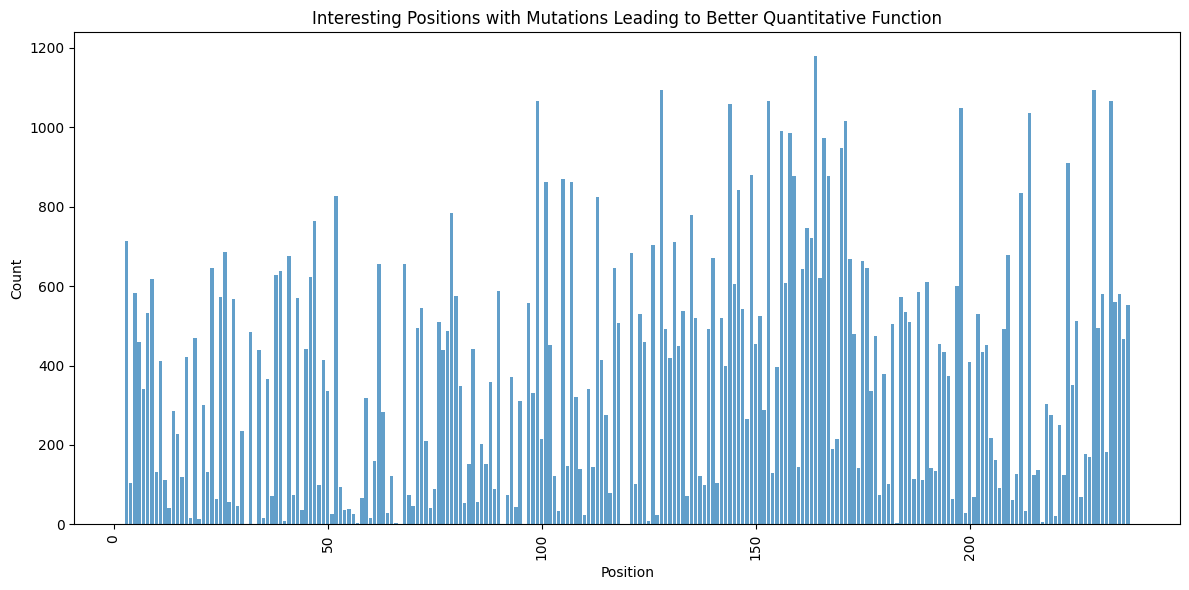

In [ ]:
# Example usage
sark_path = Path("/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/N00_raw_datasets_processed/GFP/sarkisyan.csv")
luke_AVGFP_AA_SEQ = 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'

result_df, interesting_positions = analyze_mutations_and_plot(sark_path, luke_AVGFP_AA_SEQ)

In [ ]:
result_df

,SEQ,quantitative_function,num_mutations,mutations,above_mean_q_function
0,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.858878,0,,True
1,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.007405,1,A110D,False
2,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.007405,5,"A110D, N146D, I188V, M233T, L236P",False
3,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.007461,4,"A110D, Y143N, H148L, E222G",False
4,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.855098,1,A110G,True
...,...,...,...,...,...
51710,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.095806,3,"Y92N, N105S, I171F",False
51711,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.007405,5,"Y92N, Q177L, L207Q, T230A, M233V",False
51712,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.007405,3,"Y92R, I152N, N198S",False
51713,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,0.007576,3,"Y92R, I167T, L236P",False


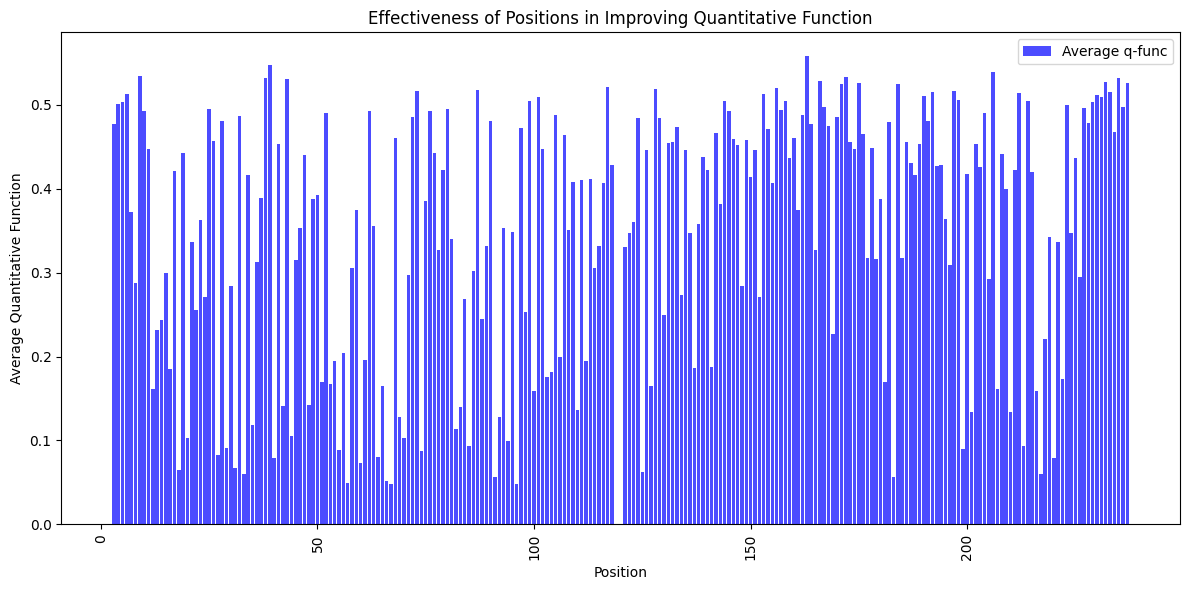

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

def analyze_effective_positions(dataset_path, wild_type_seq):
    # Load the dataset
    df = pd.read_csv(dataset_path)

    # Ensure the dataset has the required columns
    if not {'SEQ', 'quantitative_function'}.issubset(df.columns):
        raise ValueError("Dataset must contain 'SEQ' and 'quantitative_function' columns.")

    # Drop the id column if it exists
    if 'id' in df.columns:
        df = df[['SEQ', 'quantitative_function']]

    # Initialize columns for mutation data
    wild_type_len = len(wild_type_seq)
    position_effects = defaultdict(list)  # To store q-func values for each position

    for _, row in df.iterrows():
        seq = row['SEQ']
        q_func = row['quantitative_function']
        if len(seq) != wild_type_len:
            raise ValueError(f"Sequence length mismatch for sequence: {seq}")

        # Record positions where mutations occurred (res = residue)
        for pos, (wt_res, res) in enumerate(zip(wild_type_seq, seq), start=1):
            if wt_res != res:  # Mutation occurred
                position_effects[pos].append(q_func)

    # Analyze position impacts
    position_stats = []
    for pos, q_func_values in position_effects.items():
        avg_q_func = np.mean(q_func_values)  # Mean q-func for mutations at this position
        position_stats.append((pos, avg_q_func, len(q_func_values)))

    # Sort positions by average q-func
    position_stats = sorted(position_stats, key=lambda x: x[1], reverse=True)

    # Extract data for visualization
    positions = [x[0] for x in position_stats]
    avg_q_funcs = [x[1] for x in position_stats]
    mutation_counts = [x[2] for x in position_stats]

    # Plot the impact of positions
    plt.figure(figsize=(12, 6))
    plt.bar(positions, avg_q_funcs, alpha=0.7, color='blue', label='Average q-func')
    plt.xlabel('Position')
    plt.ylabel('Average Quantitative Function')
    plt.title('Effectiveness of Positions in Improving Quantitative Function')
    plt.xticks(rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(position_stats, columns=['Position', 'Average_q_func', 'Mutation_Count'])

# Example usage
sark_path = Path("/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/N00_raw_datasets_processed/GFP/sarkisyan.csv")
luke_AVGFP_AA_SEQ = 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'

position_effects_df = analyze_effective_positions(sark_path, luke_AVGFP_AA_SEQ)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

def find_interesting_positions(dataset_path, wild_type_seq, top_percentile=0.1):
    """
    Identify and visualize positions most associated with the best quantitative function values.

    Args:
        dataset_path (Path): Path to the CSV file with ID, SEQ, and quantitative_function columns.
        wild_type_seq (str): Wild-type sequence.
        top_percentile (float): Proportion of top-performing sequences to analyze (default: top 10%).

    Returns:
        pd.DataFrame: Summary of positions with frequency and their contribution to top quantitative function values.
    """
    # Load the dataset
    df = pd.read_csv(dataset_path)

    # Ensure the dataset has the required columns
    if not {'SEQ', 'quantitative_function'}.issubset(df.columns):
        raise ValueError("Dataset must contain 'SEQ' and 'quantitative_function' columns.")

    # Sort the dataset by quantitative function to identify top performers
    threshold = np.percentile(df['quantitative_function'], 100 * (1 - top_percentile))
    top_sequences = df[df['quantitative_function'] >= threshold]

    # Analyze mutations for the top sequences
    wild_type_len = len(wild_type_seq)
    mutation_positions = Counter()

    for _, row in top_sequences.iterrows():
        seq = row['SEQ']
        if len(seq) != wild_type_len:
            raise ValueError(f"Sequence length mismatch for sequence: {seq}")

        # Track mutation positions
        for pos, (wt_res, res) in enumerate(zip(wild_type_seq, seq), start=1):
            if wt_res != res:  # Mutation occurred
                mutation_positions[pos] += 1

    # Convert results to a DataFrame for better analysis
    mutation_summary = pd.DataFrame.from_dict(
        mutation_positions, orient='index', columns=['Frequency']
    ).reset_index().rename(columns={'index': 'Position'})

    # Sort by frequency to highlight the most interesting positions
    mutation_summary = mutation_summary.sort_values(by='Frequency', ascending=False)

    # # Plotting: Bar Plot
    # plt.figure(figsize=(12, 6))
    # plt.bar(mutation_summary['Position'], mutation_summary['Frequency'], alpha=0.7, color='blue')
    # plt.title(f'Most Interesting Positions in Top {top_percentile*100}% Quantitative Function Values')
    # plt.xlabel('Position')
    # plt.ylabel('Mutation Frequency')
    # plt.xticks(rotation=90)
    # plt.tight_layout()
    # plt.show()

    return mutation_summary

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


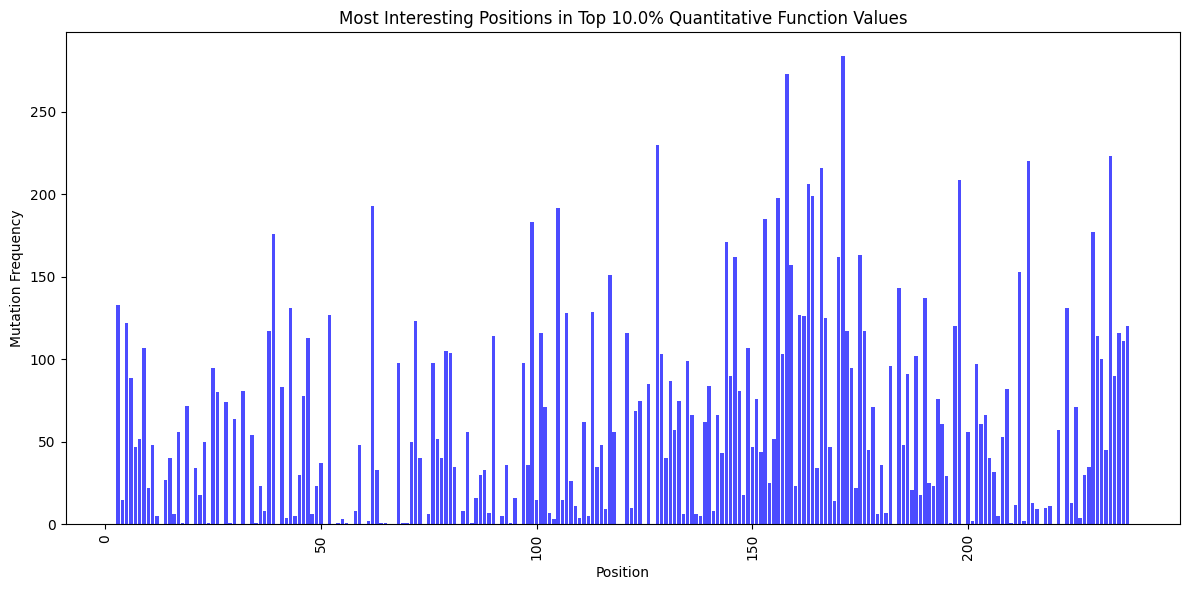

In [ ]:
# Example usage
sark_path = Path("/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/N00_raw_datasets_processed/GFP/sarkisyan.csv")
luke_AVGFP_AA_SEQ = 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'
top_percentile=0.1

interesting_positions_df = find_interesting_positions(sark_path, luke_AVGFP_AA_SEQ, top_percentile)

In [ ]:
interesting_positions_df.head(10)

,Position,Frequency
41,171,284
24,158,273
18,128,230
69,233,223
31,214,220
64,166,216
26,198,209
20,163,206
8,164,199
86,156,198


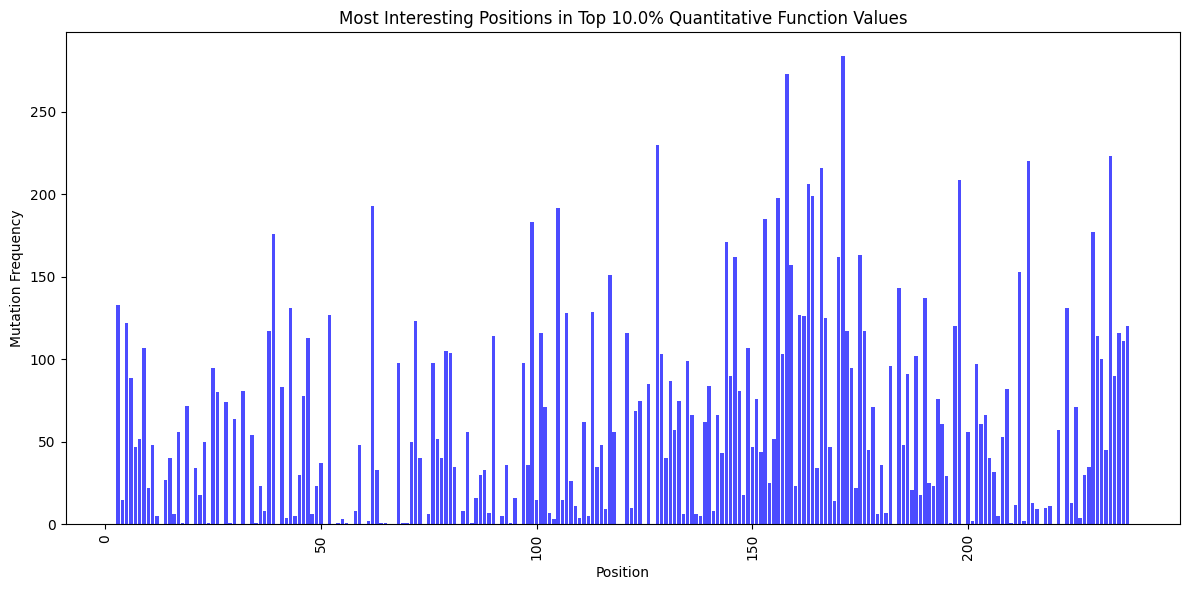

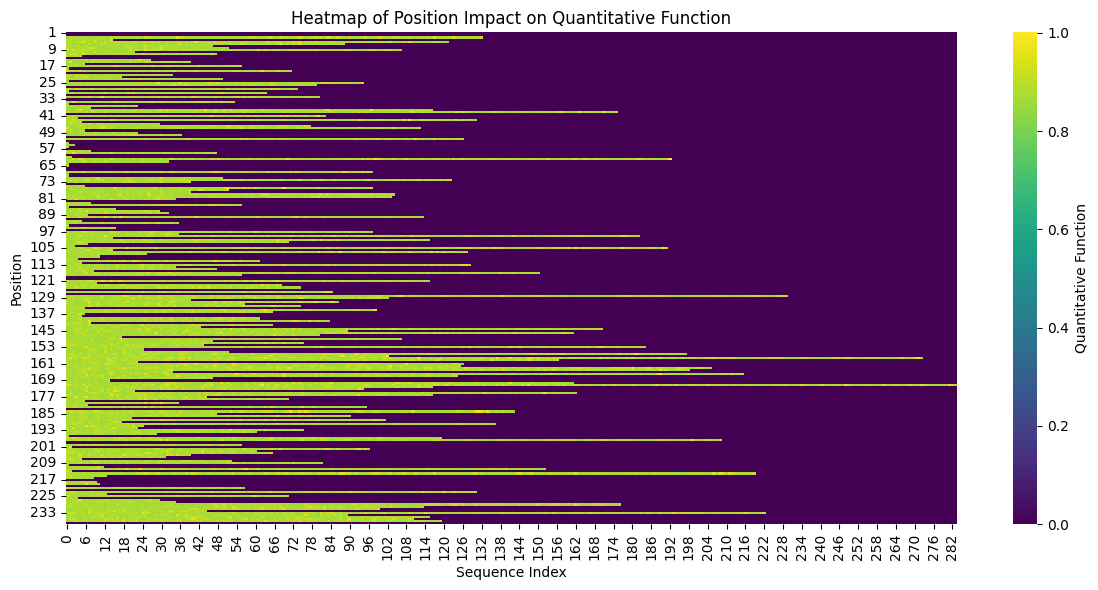

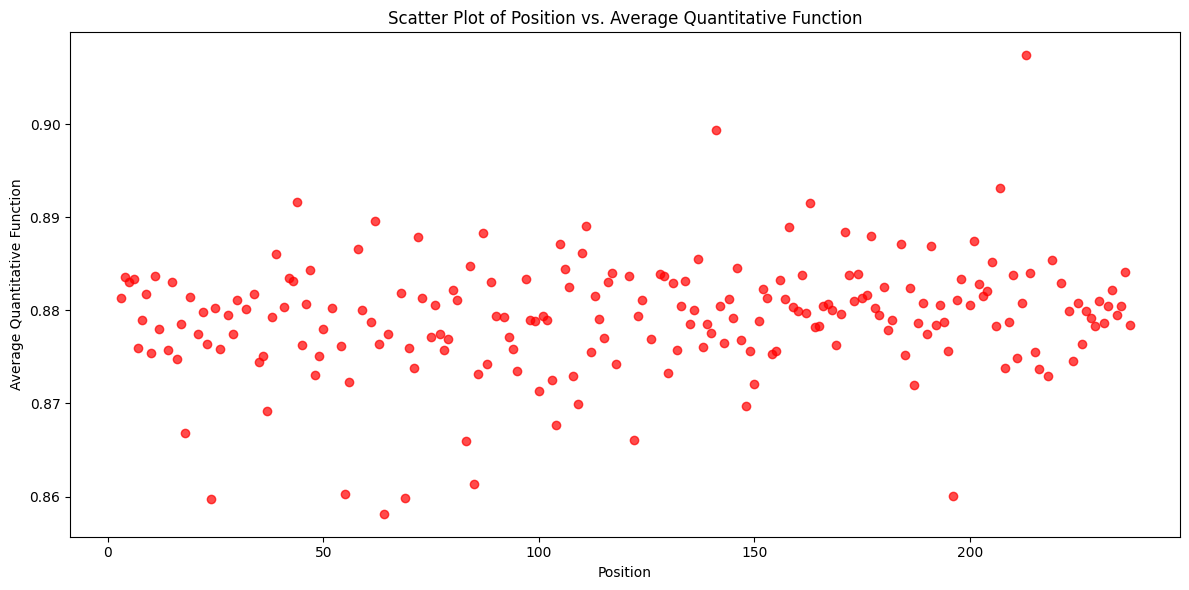

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import seaborn as sns

def find_interesting_positions(dataset_path, wild_type_seq, top_percentile=0.1):
    """
    Identify and visualize positions most associated with the best quantitative function values.

    Args:
        dataset_path (Path): Path to the CSV file with ID, SEQ, and quantitative_function columns.
        wild_type_seq (str): Wild-type sequence.
        top_percentile (float): Proportion of top-performing sequences to analyze (default: top 10%).

    Returns:
        pd.DataFrame: Summary of positions with frequency and their contribution to top quantitative function values.
    """
    # Load the dataset
    df = pd.read_csv(dataset_path)

    # Ensure the dataset has the required columns
    if not {'SEQ', 'quantitative_function'}.issubset(df.columns):
        raise ValueError("Dataset must contain 'SEQ' and 'quantitative_function' columns.")

    # Sort the dataset by quantitative function to identify top performers
    threshold = np.percentile(df['quantitative_function'], 100 * (1 - top_percentile))
    top_sequences = df[df['quantitative_function'] >= threshold]

    # Analyze mutations for the top sequences
    wild_type_len = len(wild_type_seq)
    mutation_positions = Counter()
    position_impact = {pos: [] for pos in range(1, wild_type_len + 1)}

    for _, row in top_sequences.iterrows():
        seq = row['SEQ']
        q_func = row['quantitative_function']
        if len(seq) != wild_type_len:
            raise ValueError(f"Sequence length mismatch for sequence: {seq}")

        # Track mutation positions
        for pos, (wt_res, res) in enumerate(zip(wild_type_seq, seq), start=1):
            if wt_res != res:  # Mutation occurred
                mutation_positions[pos] += 1
                position_impact[pos].append(q_func)

    # Convert results to a DataFrame for better analysis
    mutation_summary = pd.DataFrame.from_dict(
        mutation_positions, orient='index', columns=['Frequency']
    ).reset_index().rename(columns={'index': 'Position'})

    # Calculate average q-func for each position
    mutation_summary['Average_q_func'] = mutation_summary['Position'].apply(
        lambda pos: np.mean(position_impact[pos]) if pos in position_impact else 0
    )

    # Sort by frequency to highlight the most interesting positions
    mutation_summary = mutation_summary.sort_values(by='Frequency', ascending=False)

    # Plotting: Bar Plot
    plt.figure(figsize=(12, 6))
    plt.bar(mutation_summary['Position'], mutation_summary['Frequency'], alpha=0.7, color='blue')
    plt.title(f'Most Interesting Positions in Top {top_percentile*100}% Quantitative Function Values')
    plt.xlabel('Position')
    plt.ylabel('Mutation Frequency')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    # Plotting: Heatmap
    heatmap_data = pd.DataFrame.from_dict(position_impact, orient='index').fillna(0)
    plt.figure(figsize=(12, 6))
    sns.heatmap(heatmap_data, cmap='viridis', cbar_kws={'label': 'Quantitative Function'})
    plt.title('Heatmap of Position Impact on Quantitative Function')
    plt.xlabel('Sequence Index')
    plt.ylabel('Position')
    plt.tight_layout()
    plt.show()

    # Plotting: Scatter Plot
    plt.figure(figsize=(12, 6))
    plt.scatter(mutation_summary['Position'], mutation_summary['Average_q_func'], alpha=0.7, color='red')
    plt.title('Scatter Plot of Position vs. Average Quantitative Function')
    plt.xlabel('Position')
    plt.ylabel('Average Quantitative Function')
    plt.tight_layout()
    plt.show()

    return mutation_summary

# Example usage
sark_path = Path("/content/drive/MyDrive/Colab Notebooks/Marjan/seq-to-func/0A - marjan/N_DataProcessing/N00_raw_datasets_processed/GFP/sarkisyan.csv")
luke_AVGFP_AA_SEQ = 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK'

interesting_positions_df = find_interesting_positions(sark_path, luke_AVGFP_AA_SEQ)
